ANOTHER TRIAL - Implementation of the ITP with Gram Schmidt Orthogonalisation

- Implementation SUCCESSFUL !!!
- Initially modified for first excited state only, later added further modifications for the higher states
- Excellent agreement with the Coulomb potenial values, minor differences as the softcore parameter 'a' was adjusted only for the GS here.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import sparse

""" new fn: count the number of nodes in the implementation"""
def count_nodes(psi):
    return np.sum(np.abs(np.diff(np.sign(psi))) / 2)

# creates the matrices necessary for CN
def create_Apl_Ami_Heff_M2_matrices(r_vec, V_vec, Z, ell, deltaTau):
    Delta_r = r_vec[1] - r_vec[0]
    N = len(r_vec)
    
    D_lower = np.ones(N-1, dtype=complex)/(Delta_r**2)
    D_upper = np.ones(N-1, dtype=complex)/(Delta_r**2)
    D_diag = -2*np.ones(N, dtype=complex)/(Delta_r**2)
    
    D_11_corr = -2*(1 - (Z*Delta_r)/(12 - 10*Z*Delta_r))/(Delta_r**2)
    if ell == 0:
        D_diag[0] = D_11_corr
    
    D = get_sparseMatrix(D_lower, D_diag, D_upper)
    
    M_2_lower = -np.ones(N-1, dtype=complex)/6
    M_2_diag = -10*np.ones(N, dtype=complex)/6
    M_2_upper = -np.ones(N-1, dtype=complex)/6
    if ell == 0:
        M_2_diag[0] = -2*(1 + (Delta_r**2)*D_11_corr/12)
    M_2 = get_sparseMatrix(M_2_lower, M_2_diag, M_2_upper)
    
    V_matrix = sparse.spdiags([V_vec], [0], N, N)
    
    # Hamiltonian (effective)
    H_2 = D + M_2@V_matrix
    
    # CN A matrices
    A_pl = M_2 + 0.5j * deltaTau * H_2
    A_mi = M_2 - 0.5j * deltaTau * H_2
    return A_pl, A_mi, H_2, M_2

def get_sparseMatrix(upper, mid, lower):
    return sparse.diags([lower, mid, upper], offsets=[-1, 0, 1], format="csr")

# Crank-Nicolson propagation
def CN_propagation(A_pl, A_mi, psi, r, N_iter=1000):
    A_pl_lower = get_lower(A_pl)
    A_pl_diag = get_diag(A_pl)
    A_pl_upper = get_upper(A_pl)
    
    for i in (range(N_iter)): # Iterate for imaginary time
        psi_new = thomas_algorithm(A_pl_lower, A_pl_diag, A_pl_upper, A_mi @ psi)
        psi = normalize(psi_new, r)
    return psi

# Compute energy (expectation value of Hamiltonian)
def calc_E_withNumerov(psi, H_2, M_2, r):
    return project(psi, H_2 @ psi, r)/project(psi, M_2 @ psi, r)


def get_diag(mat):
    return np.array([mat[i, i] for i in range(mat.shape[0])], dtype=complex)
def get_upper(mat):
    return np.array([mat[i-1, i] for i in range(1, mat.shape[0])], dtype=complex)
def get_lower(mat):
    return np.array([mat[i, i-1] for i in range(1, mat.shape[0])], dtype=complex)

# general scalar projection function
def project(psi1, psi2, r_vec):
    return np.trapz(np.conj(psi1)*psi2, x=r_vec)
def normalize(psi, r_vec):
    return psi/np.sqrt(project(psi, psi, r_vec))

def thomas_algorithm(a, b, c, d):
    n = len(b)
    
    # Create copies of the input arrays to modify during elimination
    bp = np.copy(b).astype(complex) # diagonal copy
    dp = np.copy(d).astype(complex) # Right-hand side copy
    
    # Forward elimination
    for i in range(1, n):
        # Modify the coefficients in the sub-diagonal and right-hand side
        w = a[i-1] / bp[i-1]
        bp[i] = b[i] - w * c[i-1]
        dp[i] = d[i] - w * dp[i-1]
    
    # Back substitution
    x = np.zeros(n, dtype=complex)
    x[-1] = dp[-1] / bp[-1]
    for i in range(n-2, -1, -1):
        x[i] = (dp[i] - c[i] * x[i+1]) / bp[i]
    return x

In [2]:
# loading data from previous calculations
a = 0.00823974609375
psi0 = np.load("psi0.npy") # the eigenstate till now

# Constants, for the Hydrogen case, 2P
Z = 1
ell = 0 
desiredNodes = 2 - ell - 1 # n - l - 1

# grid details
Delta_r = 0.2
N = 500
r_vec = np.linspace(Delta_r, N * Delta_r, N) 

V_softcore_vec = -1/np.sqrt(r_vec**2 + a**2)

# Imaginary time step (Δτ), based on the current energy level
delta = -0.9
E_k = -0.5
Delta_tau = 2*delta/E_k
imagDeltaTau = (-1j*Delta_tau)


# modifications applied to allow for higher excited state ITP
# psi-lowers is a list here, contains all the states to be eliminated, in each iteration of the calculations
def CN_propagation_modified2(A_pl, A_mi, psi_current , psi_lowers, r, N_iter=1000):
    
    
    A_pl_lower = get_lower(A_pl)
    A_pl_diag = get_diag(A_pl)
    A_pl_upper = get_upper(A_pl)
    
    for i in (range(N_iter)):
        psi_forITP = psi_current # lower states to be removed from this
        
        i = 0
        for psi_lower in psi_lowers:
            # print(i, len(psi_lowers))
            i+=1
            psi_forITP = psi_forITP - project(psi_lower, psi_current, r_vec) * psi_lower
        
        psi_ITP_propagated = thomas_algorithm(A_pl_lower, A_pl_diag, A_pl_upper, A_mi @ psi_forITP) 
        psi_next = normalize(psi_ITP_propagated, r) 
        
        psi_current = psi_next
    return psi_current



# modification applied to allow for 1st excited state ITP
def CN_propagation_modified(A_pl, A_mi, psi_current, psi0, r, N_iter=1000):
    A_pl_lower = get_lower(A_pl)
    A_pl_diag = get_diag(A_pl)
    A_pl_upper = get_upper(A_pl)
    
    for i in (range(N_iter)):
        # psiOld = psi1_(0): Normalised ; psi1_(1): Normalised
        psi_forITP = psi_current - project(psi0, psi_current, r_vec) * psi0 #psi1_(0) : GM Orthgonalised; psi1_(1) : GM Orthogonalised
        
        psi_ITP_propagated = thomas_algorithm(A_pl_lower, A_pl_diag, A_pl_upper, A_mi @ psi_forITP) #psi1_(1) ; psi1_(2)
        psi_next = normalize(psi_ITP_propagated, r) # psi1_1: Normalised ; psi1_(2): normalised
        
        # for the next iteration
        psi_current = psi_next # psi1_1: Normalised ; psi1_(2): Normalised
    return psi_current

(-0.1256862276173685-0j) (-0.12568622761736864-0j)


/home/soumyajeet/miniconda3/envs/computational/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/soumyajeet/miniconda3/envs/computational/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


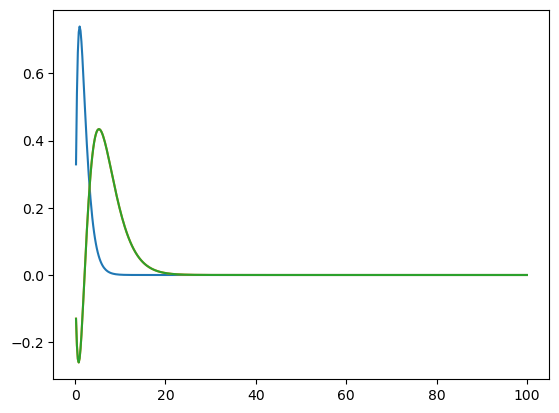

In [3]:
A_pl, A_mi, H_2, M_2 = create_Apl_Ami_Heff_M2_matrices(r_vec, V_softcore_vec, Z, ell, imagDeltaTau)

# Initial wavefunction (guessed) for the first excited state again
psi1 = np.random.random(N).astype(complex) #psi1_(0) : unnormalised
psi1 = normalize(psi1, r_vec) #psi1_(0) : normalised

psi1 = CN_propagation_modified(A_pl, A_mi, psi1, psi0, r_vec, N_iter = 1000)
psi1 = normalize(psi1, r_vec)

psi1_different = CN_propagation_modified2(A_pl, A_mi, psi1, psi_lowers=[psi0], r = r_vec, N_iter=1000)
psi1_different = normalize(psi1_different, r_vec)

plt.plot(r_vec, psi0)
plt.plot(r_vec, psi1)
plt.plot(r_vec, psi1_different)
E1 = calc_E_withNumerov(psi1, H_2, M_2, r_vec)
print(E1, calc_E_withNumerov(psi1_different, H_2, M_2, r_vec))

# alternate method to eliminate more than one lower state works for this implementation

(-0.05597280725914493-0j)


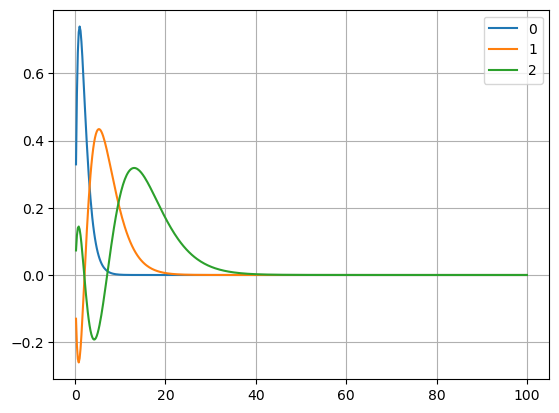

In [4]:
A_pl, A_mi, H_2, M_2 = create_Apl_Ami_Heff_M2_matrices(r_vec, V_softcore_vec, Z, ell, imagDeltaTau)

psi2 = np.random.random(N).astype(complex) 
psi2 = normalize(psi2, r_vec)

psi2 = CN_propagation_modified2(A_pl, A_mi, psi2, psi_lowers = [psi1, psi0], r = r_vec, N_iter = 1000)
psi2 = normalize(psi2, r_vec)

plt.plot(r_vec, psi0, label = "0")
plt.plot(r_vec, psi1, label = "1")
plt.plot(r_vec, psi2, label = "2")
plt.legend()
plt.grid(True)
E2 = calc_E_withNumerov(psi2, H_2, M_2, r_vec)
print(E2)

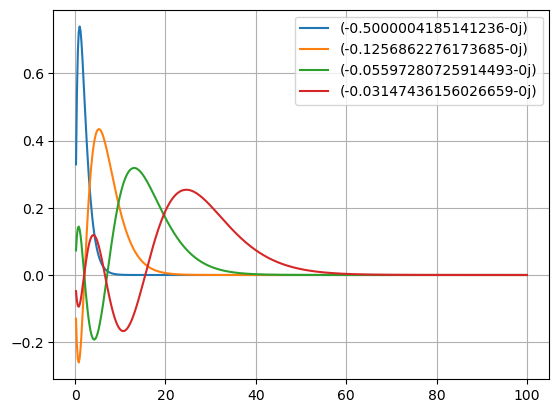

In [5]:
A_pl, A_mi, H_2, M_2 = create_Apl_Ami_Heff_M2_matrices(r_vec, V_softcore_vec, Z, ell, imagDeltaTau)

psi3 = np.random.random(N).astype(complex) 
psi3 = normalize(psi3, r_vec)

psi3 = CN_propagation_modified2(A_pl, A_mi, psi3, psi_lowers = [psi2, psi1, psi0], r = r_vec, N_iter = 1000)
psi3 = normalize(psi3, r_vec)

plt.plot(r_vec, psi0, label = calc_E_withNumerov(psi0, H_2, M_2, r_vec))
plt.plot(r_vec, psi1, label = calc_E_withNumerov(psi1, H_2, M_2, r_vec))
plt.plot(r_vec, psi2, label = calc_E_withNumerov(psi2, H_2, M_2, r_vec))
plt.plot(r_vec, psi3, label = calc_E_withNumerov(psi3, H_2, M_2, r_vec))
plt.legend()
plt.grid(True)